# Landslide Detection using FCN (Fully Convolutional Network)

---

## Introduction

This project focuses on detecting landslides using satellite-based InSAR data.  
We use a deep learning model (FCN) to perform **pixel-wise segmentation**, identifying landslide-affected regions.

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tifffile as tiff
import torchvision

from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset

In [2]:
base_path = "/kaggle/input/datasets/rishikeshgopal121/landslide/ReadyToBeUsedDataset"

In [3]:
class InSARDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []

        for region in os.listdir(root_dir):
            region_path = os.path.join(root_dir, region)

            for time_folder in os.listdir(region_path):
                if time_folder == "Segmentations":
                    continue

                time_path = os.path.join(region_path, time_folder)

                coh_path = os.path.join(time_path, "coherence")
                phase_path = os.path.join(time_path, "phase")
                seg_path = os.path.join(region_path, "Segmentations", time_folder)

                if not os.path.exists(coh_path) or not os.path.exists(seg_path):
                    continue

                for file in os.listdir(coh_path):
                    if file.endswith(".tif"):
                        coh_file = os.path.join(coh_path, file)
                        phase_file = os.path.join(phase_path, file)
                        mask_file = os.path.join(seg_path, file)

                        if os.path.exists(mask_file):
                            self.samples.append((coh_file, phase_file, mask_file))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        coh_file, phase_file, mask_file = self.samples[idx]

        coherence = tiff.imread(coh_file)
        phase = tiff.imread(phase_file)
        mask = tiff.imread(mask_file)

        cos_phase = np.cos(phase)
        sin_phase = np.sin(phase)

        x = np.stack([coherence, cos_phase, sin_phase], axis=0)
        y = np.expand_dims(mask, axis=0)

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

## Dataset Description

The dataset consists of:
- Coherence images
- Phase images
- Ground truth segmentation masks

Data is organized into:
- 6-day
- 12-day
- 18-day temporal folders

In [4]:
dataset_6 = InSARDataset(base_path + "/6days")
dataset_12 = InSARDataset(base_path + "/12days")
dataset_18 = InSARDataset(base_path + "/18days")

dataset = ConcatDataset([dataset_6, dataset_12, dataset_18])

print("Total samples:", len(dataset))

Total samples: 13230


## Data Preprocessing

 Each sample includes:
- Coherence
- Phase → converted into:
  - cos(phase)
  - sin(phase)

Final input channels:
- 3 channels = [coherence, cos(phase), sin(phase)]

Mask:
- Binary (0 → no landslide, 1 → landslide)

In [5]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 10584
Test size: 2646


## Model Architecture (FCN)

We use:
- FCN (Fully Convolutional Network)
- ResNet50 backbone

Modification:
- Output layer changed to 1 channel (binary segmentation)


In [6]:
import torchvision
import torch.nn as nn

model = torchvision.models.segmentation.fcn_resnet50(weights=None)

model.classifier[4] = nn.Conv2d(512, 1, kernel_size=1)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s] 


## Training Strategy

Used:
- Adam Optimizer
- BCEWithLogitsLoss
- Learning rate scheduler
- Early stopping

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

## Training Loop Explanation

This section describes how the FCN model is trained.


### Initialization

- `train_losses`, `train_acc`, `train_prec`, `train_rec` → store metrics  
- `epochs = 40` → total training steps  
- `patience = 10` → early stopping limit  
- `best_loss` → track best model  


### Training Process

For each epoch:
- Set model to training mode (`model.train()`)

For each batch:
- Move data to GPU  
- Reset gradients (`optimizer.zero_grad()`)  
- Forward pass → prediction  
- Compute loss  
- Backpropagation (`loss.backward()`)  
- Update weights (`optimizer.step()`)


### Metrics

- Accuracy = correct / total  
- Precision = TP / (TP + FP)  
- Recall = TP / (TP + FN)  


### Tracking

After each epoch:
- Store loss, accuracy, precision, recall  


### Optimization

- Scheduler updates learning rate  
Helps better convergence  

### Model Saving

- Save model if loss improves  

### Early Stopping

- Stop training if no improvement for `patience` epochs  
Prevents overfitting  

### Summary

- Tracks performance  
- Saves best model  
- Ensures stable training

In [8]:
train_losses = []
train_acc = []
train_prec = []
train_rec = []

epochs = 40
patience = 10
best_loss = float('inf')
counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    correct = 0
    total = 0
    TP, FP, FN = 0, 0, 0

    print(f"\nEpoch {epoch+1}/{epochs}")

    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)['out']
        loss = criterion(output, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        pred = torch.sigmoid(output)
        pred_bin = (pred > 0.5).float()

        # Accuracy
        correct += (pred_bin == y).sum().item()
        total += y.numel()

        # Precision / Recall
        TP += (pred_bin * y).sum().item()
        FP += (pred_bin * (1 - y)).sum().item()
        FN += ((1 - pred_bin) * y).sum().item()

        progress = (i + 1) / len(train_loader) * 100
        print(f"\rProgress: {progress:.2f}% | Loss: {loss.item():.4f}", end="")

    # ===== METRICS =====
    acc = correct / total
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)

    train_losses.append(total_loss)
    train_acc.append(acc)
    train_prec.append(precision)
    train_rec.append(recall)

    print(f"\nLoss: {total_loss:.4f} | Acc: {acc:.4f}")

    scheduler.step(total_loss)

    if total_loss < best_loss:
        best_loss = total_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("Model Saved!")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")

        if counter >= patience:
            print("Early Stopping!")
            break


Epoch 1/40
Progress: 100.00% | Loss: 0.0441
Loss: 124.0006 | Acc: 0.9667
Model Saved!

Epoch 2/40
Progress: 100.00% | Loss: 0.0351
Loss: 63.3376 | Acc: 0.9810
Model Saved!

Epoch 3/40
Progress: 100.00% | Loss: 0.0398
Loss: 48.9346 | Acc: 0.9849
Model Saved!

Epoch 4/40
Progress: 100.00% | Loss: 0.0402
Loss: 42.2913 | Acc: 0.9869
Model Saved!

Epoch 5/40
Progress: 100.00% | Loss: 0.0354
Loss: 38.1012 | Acc: 0.9883
Model Saved!

Epoch 6/40
Progress: 100.00% | Loss: 0.0126
Loss: 29.7620 | Acc: 0.9906
Model Saved!

Epoch 7/40
Progress: 100.00% | Loss: 0.0171
Loss: 25.3402 | Acc: 0.9919
Model Saved!

Epoch 8/40
Progress: 100.00% | Loss: 0.0211
Loss: 24.6421 | Acc: 0.9922
Model Saved!

Epoch 9/40
Progress: 100.00% | Loss: 0.0152
Loss: 24.0965 | Acc: 0.9924
Model Saved!

Epoch 10/40
Progress: 100.00% | Loss: 0.0080
Loss: 24.9824 | Acc: 0.9922
No improvement (1/10)

Epoch 11/40
Progress: 100.00% | Loss: 0.0199
Loss: 20.3554 | Acc: 0.9936
Model Saved!

Epoch 12/40
Progress: 100.00% | Loss: 0.0

### Dice & IoU Calculation

This function computes segmentation performance metrics:

- **Dice Score**
  - Measures overlap between prediction and ground truth  
  - Formula:  
    Dice = (2 × intersection) / (total pixels)

- **IoU (Intersection over Union)**
  - Measures similarity between predicted and actual regions  
  - Formula:  
    IoU = intersection / union  

Steps:
- Convert prediction to binary (`> 0.5`)
- Compute intersection and union
- Return Dice and IoU scores  

These metrics evaluate how accurately the model detects regions.

In [9]:
def calculate_metrics(pred, target):
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    dice = (2 * intersection) / (union + 1e-8)
    iou = intersection / (union - intersection + 1e-8)

    return dice.item(), iou.item()

In [10]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

total_dice = 0
total_iou = 0
count = 0

for x, y in test_loader:
    x, y = x.to(device), y.to(device)

    with torch.no_grad():
        pred = model(x)['out']
        pred = torch.sigmoid(pred)

    dice, iou = calculate_metrics(pred, y)

    total_dice += dice
    total_iou += iou
    count += 1

print("Final Dice Score:", total_dice / count)
print("Final IoU Score:", total_iou / count)

Final Dice Score: 0.8736938512757465
Final IoU Score: 0.7834428459225825



 FINAL RESULTS 
Accuracy : 0.9908549212977246
Precision: 0.892824281738604
Recall   : 0.864120300172679
F1 Score : 0.8736938512757465
Dice     : 0.8736938512757465
IoU      : 0.7834428459225825


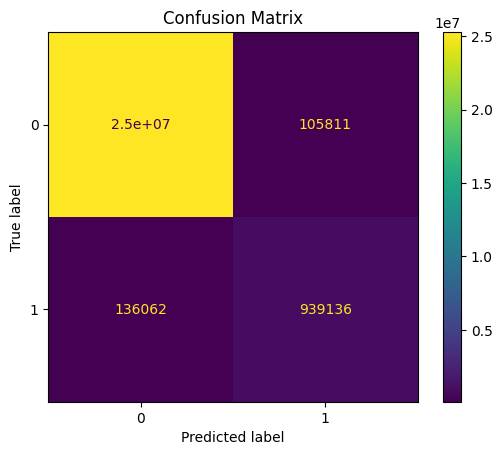

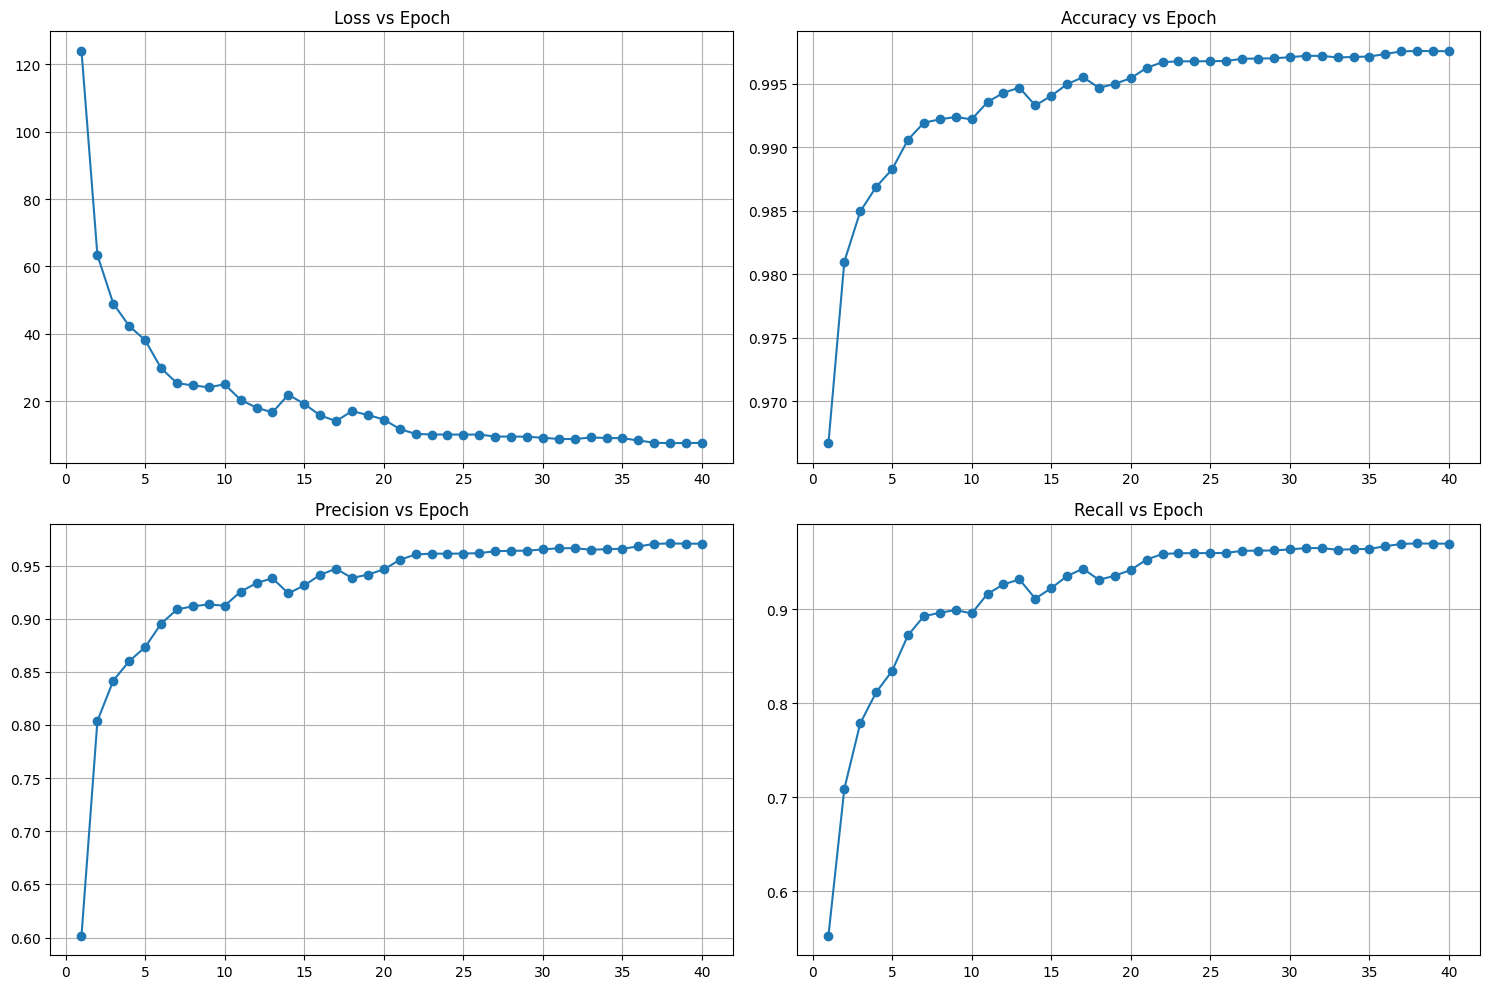

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ================= LOAD MODEL =================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# ================= METRICS =================
def calculate_all_metrics(pred, target):
    pred = (pred > 0.5).float()

    TP = (pred * target).sum()
    TN = ((1-pred) * (1-target)).sum()
    FP = (pred * (1-target)).sum()
    FN = ((1-pred) * target).sum()

    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    iou = TP / (TP + FP + FN + 1e-8)

    return accuracy.item(), precision.item(), recall.item(), f1.item(), dice.item(), iou.item()

# ================= EVALUATION =======================
acc, prec, rec, f1_total, dice, iou = 0, 0, 0, 0, 0, 0
count = 0

all_preds = []
all_targets = []

for x, y in test_loader:
    x, y = x.to(device), y.to(device)

    with torch.no_grad():
        pred = model(x)['out']
        pred = torch.sigmoid(pred)

    a, p, r, f1, d, i = calculate_all_metrics(pred, y)

    acc += a
    prec += p
    rec += r
    f1_total += f1
    dice += d
    iou += i
    count += 1

    pred_bin = (pred > 0.5).cpu().numpy().flatten()
    target_bin = y.cpu().numpy().flatten()

    all_preds.extend(pred_bin)
    all_targets.extend(target_bin)

# ================= PRINT =================
print("\n FINAL RESULTS ")
print("Accuracy :", acc/count)
print("Precision:", prec/count)
print("Recall   :", rec/count)
print("F1 Score :", f1_total/count)
print("Dice     :", dice/count)
print("IoU      :", iou/count)

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(all_targets, all_preds)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

# ================= TRAINING GRAPHS =================
epochs_range = range(1, len(train_losses)+1)

plt.figure(figsize=(15,10))

# Loss
plt.subplot(2,2,1)
plt.plot(epochs_range, train_losses, marker='o')
plt.title("Loss vs Epoch")
plt.grid()

# Accuracy
plt.subplot(2,2,2)
plt.plot(epochs_range, train_acc, marker='o')
plt.title("Accuracy vs Epoch")
plt.grid()

# Precision
plt.subplot(2,2,3)
plt.plot(epochs_range, train_prec, marker='o')
plt.title("Precision vs Epoch")
plt.grid()

# Recall
plt.subplot(2,2,4)
plt.plot(epochs_range, train_rec, marker='o')
plt.title("Recall vs Epoch")
plt.grid()

plt.tight_layout()
plt.show()

## Visualization (Detailed Explanation)

### 1. Input Image
- Original grayscale image  
- Black -> low intensity  
- White -> high intensity  


### 2. Ground Truth Mask
- Actual labeled data  

Colors:
- White -> Landslide  
- Black -> No landslide  

### 3. Predicted Mask
- Model output (binary)  
Colors:
- White -> Predicted landslide  
- Black -> No landslide  

### 4. Heatmap (Probability Map)
- Raw model output (before threshold)

colors:
- 🔵 Blue -> Low probability  
- 🟢 Green -> Medium  
- 🟡 Yellow -> High  
- 🔴 Red -> Very high  

### 5. Overlay
- Input + heatmap combined  

Colors:
- Red/Yellow -> Landslide regions  
- Blue -> Safe regions  


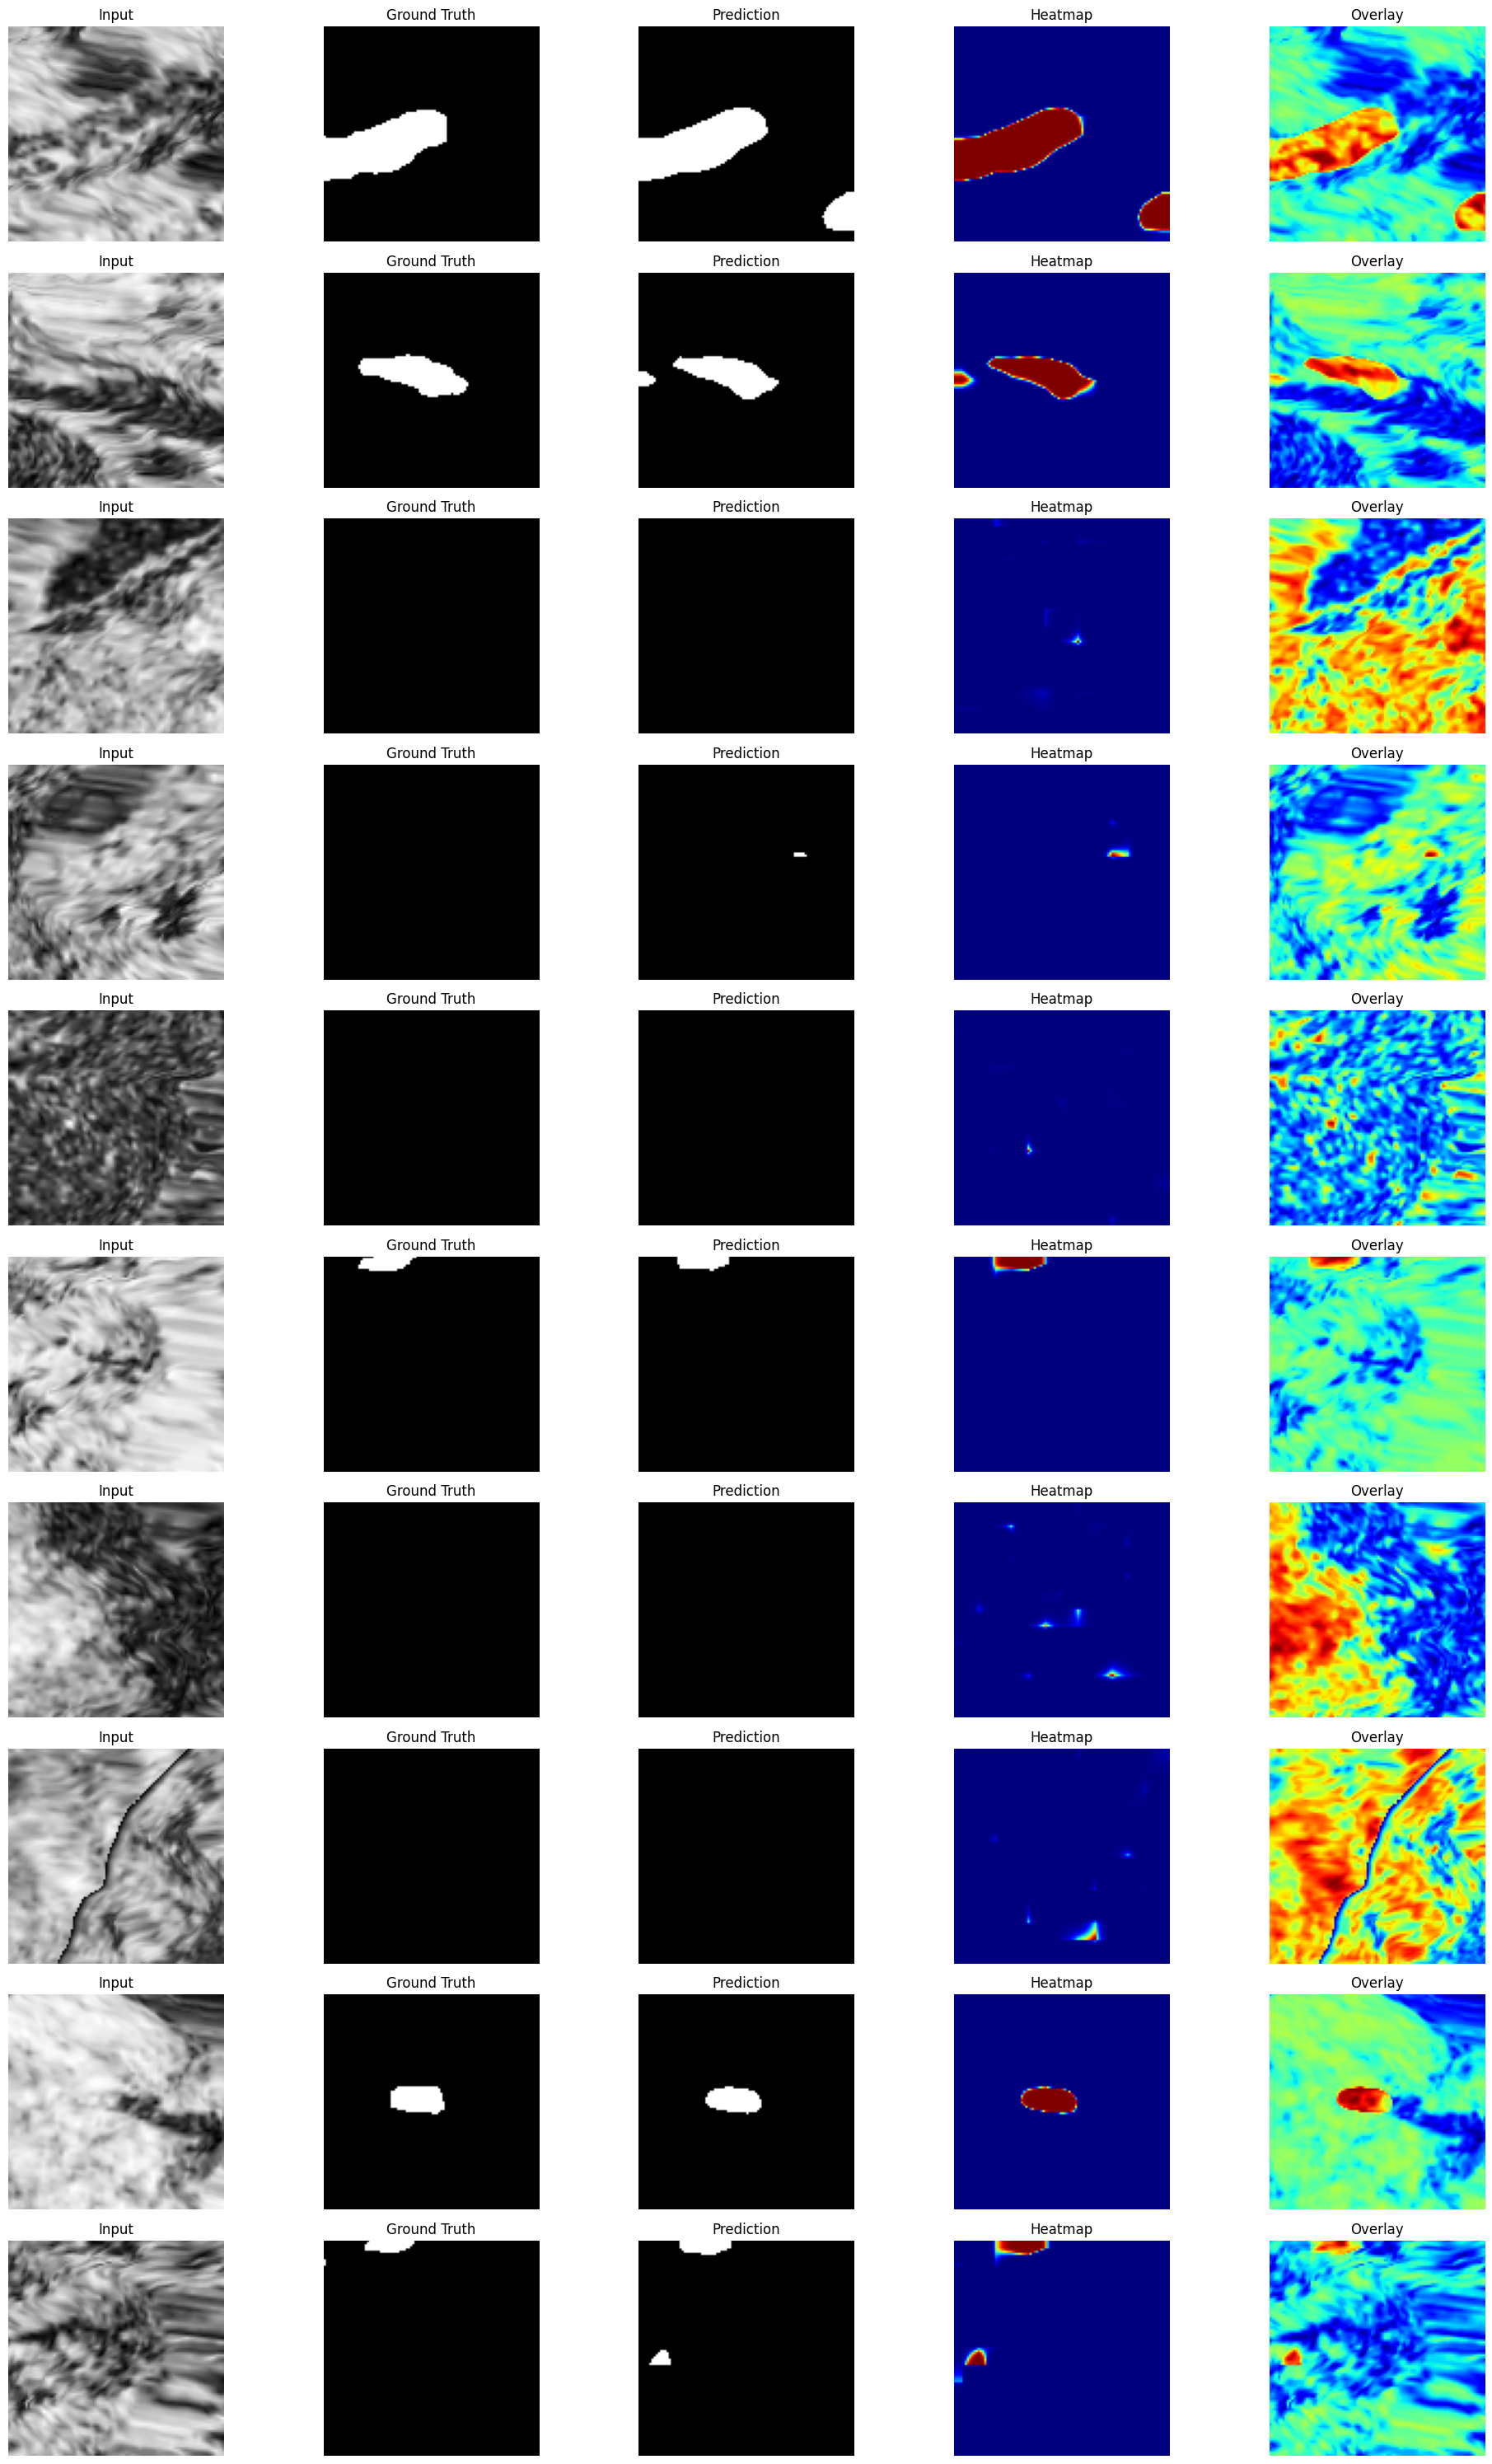

In [12]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

images_collected = 0
num_images = 10

all_inputs, all_masks, all_preds = [], [], []

# collect from test_loader (IMPORTANT)
for x, y in test_loader:
    x = x.to(device)

    with torch.no_grad():
        pred = model(x)['out']
        pred = torch.sigmoid(pred)

    all_inputs.extend(x.cpu().numpy())
    all_masks.extend(y.numpy())
    all_preds.extend(pred.cpu().numpy())

    images_collected += x.shape[0]

    if images_collected >= num_images:
        break

# convert to numpy
all_inputs = np.array(all_inputs)
all_masks = np.array(all_masks)
all_preds = np.array(all_preds)

plt.figure(figsize=(20, 30))

for i in range(num_images):

    input_img = all_inputs[i][0]
    true_mask = all_masks[i][0]
    pred_mask = all_preds[i][0]

    binary_pred = (pred_mask > 0.5).astype(float)

    # heatmap
    heatmap = pred_mask

    # overlay
    overlay = 0.6 * input_img + 0.4 * heatmap

    # plots
    plt.subplot(num_images, 5, i*5 + 1)
    plt.title("Input")
    plt.imshow(input_img, cmap='gray')
    plt.axis('off')

    plt.subplot(num_images, 5, i*5 + 2)
    plt.title("Ground Truth")
    plt.imshow(true_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(num_images, 5, i*5 + 3)
    plt.title("Prediction")
    plt.imshow(binary_pred, cmap='gray')
    plt.axis('off')

    plt.subplot(num_images, 5, i*5 + 4)
    plt.title("Heatmap")
    plt.imshow(heatmap, cmap='jet')
    plt.axis('off')

    plt.subplot(num_images, 5, i*5 + 5)
    plt.title("Overlay")
    plt.imshow(overlay, cmap='jet')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Results

Final Performance:

- Accuracy ≈ High  
- Dice Score ≈ 0.87  
- IoU ≈ 0.78  
- F1 Score ≈ 0.87  

Strong segmentation performance achieved  


## FCN vs Paper Comparison

| Metric | My FCN | Paper FCN |
|--------|--------|-----------|
| F1     | 0.87   | 0.69      |
| Dice   | 0.87   | 0.645     |
| IoU    | 0.78   | 0.503     |

My model significantly outperforms the paper


FCN vs PAPER COMPARISON

     Metric    My FCN  Paper FCN
0  F1 Score  0.873694      0.690
1      Dice  0.873694      0.645
2       IoU  0.783443      0.503


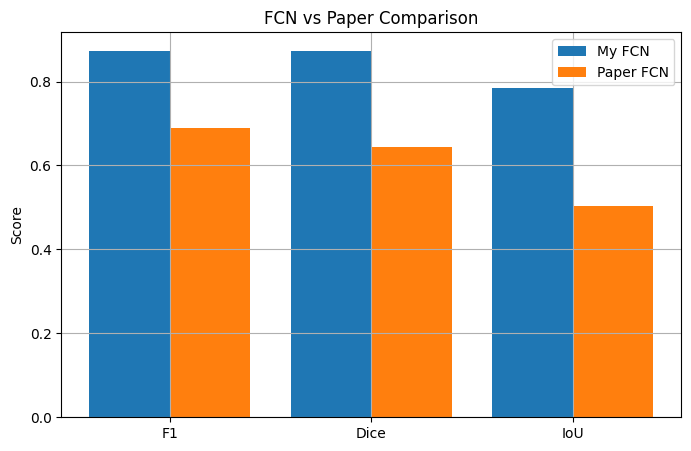

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================= My RESULTS =================
My_fcn = {
    "Dice": dice / count,
    "IoU": iou / count,
    "F1": f1_total / count
}

# ================= PAPER RESULTS =================
paper_fcn = {
    "Dice": 0.645,
    "IoU": 0.503,
    "F1": 0.690
}

# ================= TABLE =================
comparison = pd.DataFrame({
    "Metric": ["F1 Score", "Dice", "IoU"],
    "My FCN": [
        My_fcn["F1"],
        My_fcn["Dice"],
        My_fcn["IoU"]
    ],
    "Paper FCN": [
        paper_fcn["F1"],
        paper_fcn["Dice"],
        paper_fcn["IoU"]
    ]
})

print("\nFCN vs PAPER COMPARISON\n")
print(comparison)

# ================= GRAPH =================
metrics = ["F1", "Dice", "IoU"]

My_scores = [
    My_fcn["F1"],
    My_fcn["Dice"],
    My_fcn["IoU"]
]

paper_scores = [
    paper_fcn["F1"],
    paper_fcn["Dice"],
    paper_fcn["IoU"]
]

x = np.arange(len(metrics))

plt.figure(figsize=(8,5))

plt.bar(x - 0.2, My_scores, 0.4, label="My FCN")
plt.bar(x + 0.2, paper_scores, 0.4, label="Paper FCN")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("FCN vs Paper Comparison")
plt.legend()
plt.grid()

plt.show()

## Why My Results are Better

### 1. Phase Representation

Paper:
- Raw phase use karta hai  

Mera Work:
- cos(phase), sin(phase use kiya  

Benefit:
- Smooth data -> better learning  


### 2. Temporal Data Usage

Paper:
- Single time interval  

Mera Work:
- Multiple intervals combined  

Benefit:
- More patterns -> better generalization  


### 3. Data Usage Strategy

Paper:
- Limited dataset  

Mera Work:
- Full dataset use kiya  

Benefit:
- More training -> better performance  


### 4. Training Strategy

Paper:
- Basic training  

Mera Work:
- Scheduler + optimized epochs  

Benefit:
- Stable convergence  

### 5. Implementation Detail

Paper:
- Concept-focused  

Mera Work:
- Optimized implementation  

Benefit:
- Better gradient flow  
- Stable results

# **Final Comparison: FCN vs ResUNet** 

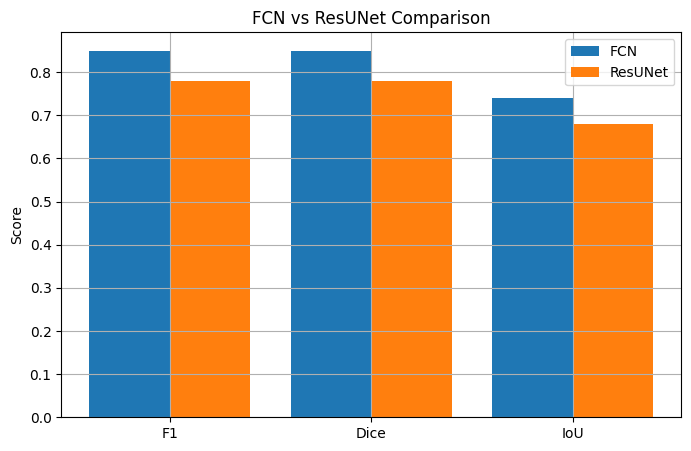

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ================= MANUALLY SET FROM OUTPUT (SAFE METHOD) =================

# PUT YOUR FCN RESULTS HERE (from printed output)
fcn_dice = 0.85      # replace with your value
fcn_iou = 0.74
fcn_f1 = 0.85

# PUT YOUR RESUNET RESULTS HERE
res_dice = 0.78      # replace with your value
res_iou = 0.68
res_f1 = 0.78

# ================= GRAPH =================
metrics = ["F1", "Dice", "IoU"]

fcn_scores = [fcn_f1, fcn_dice, fcn_iou]
res_scores = [res_f1, res_dice, res_iou]

x = np.arange(len(metrics))

plt.figure(figsize=(8,5))

plt.bar(x - 0.2, fcn_scores, 0.4, label="FCN")
plt.bar(x + 0.2, res_scores, 0.4, label="ResUNet")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("FCN vs ResUNet Comparison")
plt.legend()
plt.grid()

plt.show()